# Visualização Inicial
Notebook responsável pela visualização inicial dos dados em `/data/processed/expired_items_dataset_processed.csv`.

---
# 1. Importando Bibliotecas

Bibliotecas utilizadas para manipulação, visualização de dados e controle de avisos.

In [13]:
# bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

---
# 2. Atribuindo a Base de Dados para DataFrame 


In [14]:
# importando dataset

df = pd.read_csv(
    '../data/processed/expired_items_dataset_processed.csv'
)

---
# 3. Validação Final

Importante manter o arquivo de limpeza aberto nessa etapa para confirmar diferenças.

In [15]:
# covertendo novamente colunas para datetime

for col in ['DATA', 'VALIDADE']:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')

Colunas convertidas novamente para manipular os dados nesse notebook.

Conversão definitiva será feita em SQL. 

In [16]:
# confirma dimensões 
df.shape

(28006, 6)

In [17]:
# retorna a qnts de valores unicos em cada coluna + lista o nome das colunas

df.nunique()

DATA           370
BANDEIRA         2
LOJA            23
QUANTIDADE     212
SETOR           18
VALIDADE      1588
dtype: int64

In [18]:
# verifica se há datas de validade maiores que data de vistoria

df[df['VALIDADE']>df['DATA']] 

,DATA,BANDEIRA,LOJA,QUANTIDADE,SETOR,VALIDADE


In [19]:
# confere visualmente se os dados apresentam problemas

df.head()

,DATA,BANDEIRA,LOJA,QUANTIDADE,SETOR,VALIDADE
0,2022-01-03,JOAO,16,1,MERCEARIA COMPLEMENTAR,2021-10-20
1,2022-01-03,JOAO,16,4,MERCEARIA COMPLEMENTAR,2022-01-01
2,2022-01-03,JOAO,16,1,MERCEARIA COMPLEMENTAR,2021-12-01
3,2022-01-03,JOAO,16,2,MERCEARIA COMPLEMENTAR,2022-01-01
4,2022-01-03,JOAO,16,3,MERCEARIA COMPLEMENTAR,2021-04-30


Validações concluídas, nenhum erro identificado.

DataFrame consistente e pronto para visualizações.

---
# 4. Visualizações

## 4.1 Padronização dos gráficos

In [20]:
# criando padrao visual dos graficos

plt.rcParams.update({
    # layout
    'figure.figsize': (8,4), 
    'figure.constrained_layout.use': True,

    # cor padrão
    'axes.prop_cycle': plt.cycler(color=["#465470"]),

    # titulo
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#505050',

    # eixos 
    'axes.labelcolor':'#7C7C7C',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'xtick.color': '#7C7C7C',
    'ytick.color': '#7C7C7C',

    # grid
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'axes.axisbelow': True,

    # bordas
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
})

Configuração global de estilo dos gráficos via `rcParams` para manter consistência visual.

## 4.2 Ocorrências totais por Bandeira

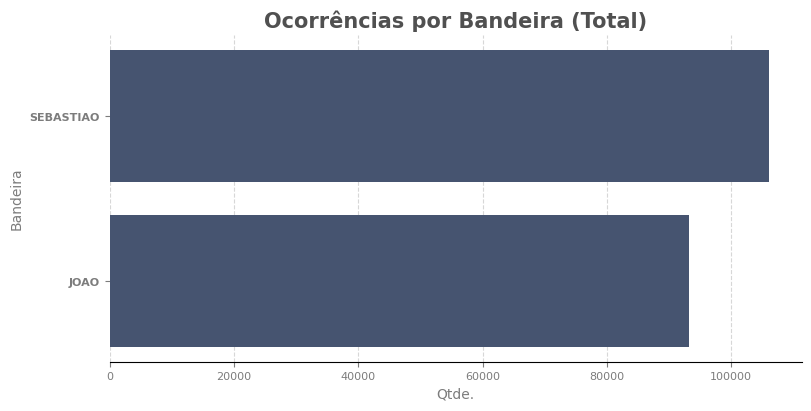

In [ ]:
qntd = df.groupby('BANDEIRA')['QUANTIDADE'].sum()       # define valores do grafico

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 

ax.barh(                                                 # grafico
    qntd.index,
    qntd.values
)
ax.set(
    title='Ocorrências por Bandeira (Total)',         # titulo
    xlabel='Qtde.',                                 # titulo eixo x
    ylabel='Bandeira'                             # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                              # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

## 4.3 Top 10 Setores com mais ocorrências

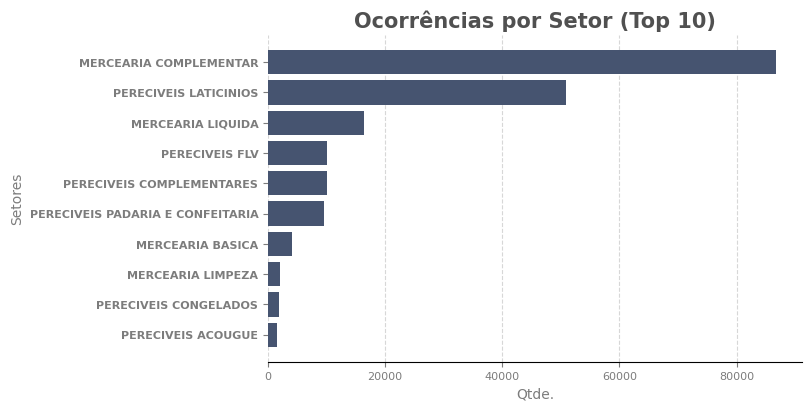

In [44]:
top10 = (                                              # define valores do grafico
    df.groupby('SETOR')['QUANTIDADE']
    .sum()
    .nlargest(10,'all')
    .sort_values()   
)

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 

ax.barh(                                                # grafico
    top10.index,
    top10.values
)
ax.set(
    title='Ocorrências por Setor (Top 10)',             # titulo
    xlabel='Qtde.',                                     # titulo eixo x
    ylabel='Setores'                                    # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                                 # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

## 4.4 Ocorrências totais por Loja

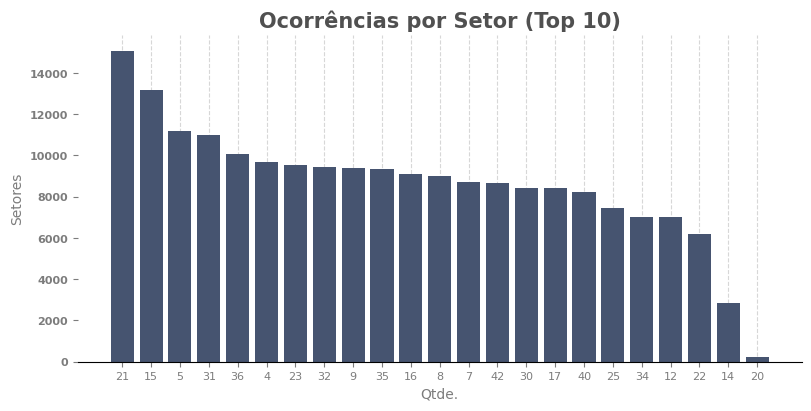

In [47]:
qntd = (                                              # define valores do grafico
    df.groupby('LOJA')['QUANTIDADE']
    .sum()
    .sort_values(ascending=False)   
)

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 

ax.bar(                                                # grafico
    qntd.index.astype(str),
    qntd.values
)
ax.set(
    title='Ocorrências por Setor (Top 10)',             # titulo
    xlabel='Qtde.',                                     # titulo eixo x
    ylabel='Setores'                                    # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                                 # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

## 4.5 Ocorrências totais por Ano

In [48]:
# extrair ano

df['ANO'] = df['DATA'].dt.year

# confirmando conversao
df['ANO'].head()

0    2022.0
1    2022.0
2    2022.0
3    2022.0
4    2022.0
Name: ANO, dtype: float64

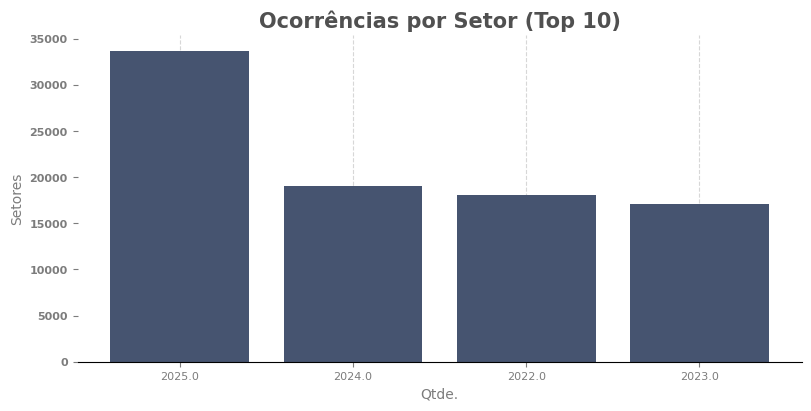

In [49]:
qntd = (                                              # define valores do grafico
    df.groupby('ANO')['QUANTIDADE']
    .sum()
    .sort_values(ascending=False)   
)

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 

ax.bar(                                                # grafico
    qntd.index.astype(str),
    qntd.values
)
ax.set(
    title='Ocorrências por Setor (Top 10)',             # titulo
    xlabel='Qtde.',                                     # titulo eixo x
    ylabel='Setores'                                    # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                                 # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()